Matplotlib is building the font cache; this may take a moment.


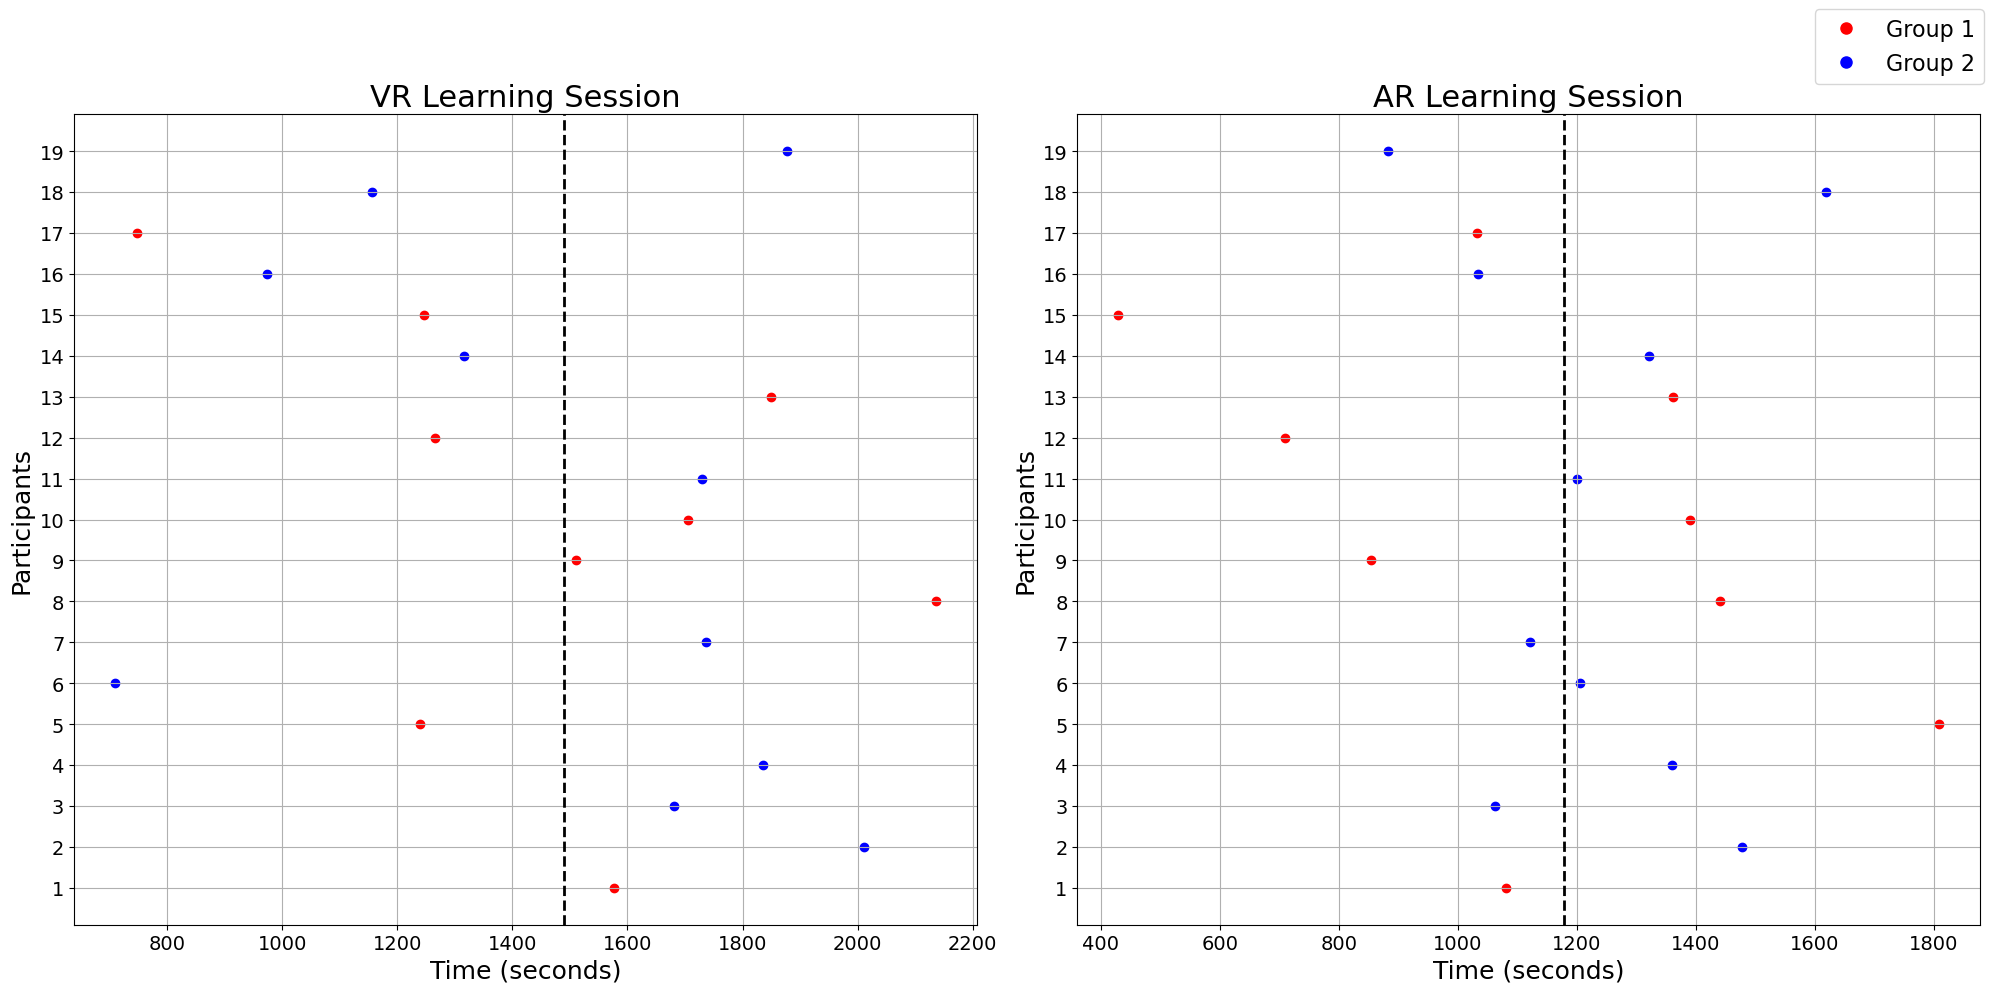

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn.cluster import KMeans


group = np.array([1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2])
vr_total_time = np.array(["26:16", "33:32", "28:01", "30:36", "20:39", "11:49", 
                          "28:57", "35:36", "25:11", "28:25", "28:50", "21:05", 
                          "30:50", "21:55", "20:46", "16:13", "12:28", "19:15", "31:17"])
ar_total_time = np.array(["18:01", "24:38", "17:42", "22:40", "30:09", "20:05", 
                          "18:41", "24:00", "14:14", "23:11", "20:00", "11:49", 
                          "22:41", "22:02", "7:09", "17:14", "17:12", "26:59", "14:43"])

def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds


vr_total_seconds = np.array([time_to_seconds(time) for time in vr_total_time])
ar_total_seconds = np.array([time_to_seconds(time) for time in ar_total_time])


X = np.column_stack((vr_total_seconds, ar_total_seconds))
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)


vr_mean_time = np.mean(vr_total_seconds)
ar_mean_time = np.mean(ar_total_seconds)


fig, ax = plt.subplots(1, 2, figsize=(20, 10))  # Increased width for better spacing


for i in range(len(vr_total_seconds)):
    color = 'red' if group[i] == 1 else 'blue'
    ax[0].scatter(vr_total_seconds[i], i + 1, color=color, marker='o')  # Marker consistent for circles

ax[0].axvline(vr_mean_time, color='black', linestyle='--', linewidth=2, label=f'Mean: {vr_mean_time:.1f} sec')
ax[0].set_title('VR Learning Session', fontsize=22)  
ax[0].set_xlabel('Time (seconds)', fontsize=18)
ax[0].set_ylabel('Participants', fontsize=18)
ax[0].tick_params(axis='x', labelsize=14)
ax[0].tick_params(axis='y', labelsize=14)
ax[0].set_yticks(range(1, 20)) 
ax[0].grid(True)


for i in range(len(ar_total_seconds)):
    color = 'red' if group[i] == 1 else 'blue'
    ax[1].scatter(ar_total_seconds[i], i + 1, color=color, marker='o')  # Marker consistent for circles

ax[1].axvline(ar_mean_time, color='black', linestyle='--', linewidth=2, label=f'Mean: {ar_mean_time:.1f} sec')
ax[1].set_title('AR Learning Session', fontsize=22)
ax[1].set_xlabel('Time (seconds)', fontsize=18)
ax[1].set_ylabel('Participants', fontsize=18)
ax[1].tick_params(axis='x', labelsize=14)
ax[1].tick_params(axis='y', labelsize=14)
ax[1].set_yticks(range(1, 20))  
ax[1].grid(True)


red_circle = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=8, label='Group 1')
blue_circle = mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=8, label='Group 2')
fig.legend(handles=[red_circle, blue_circle], loc='upper right', ncol=1, fontsize=16, bbox_to_anchor=(1, 1))


plt.tight_layout(rect=[0, 0, 1, 0.93])  
file_name = 'New_Time_Cluster_HighRes.pdf'
plt.savefig(file_name)
plt.show()

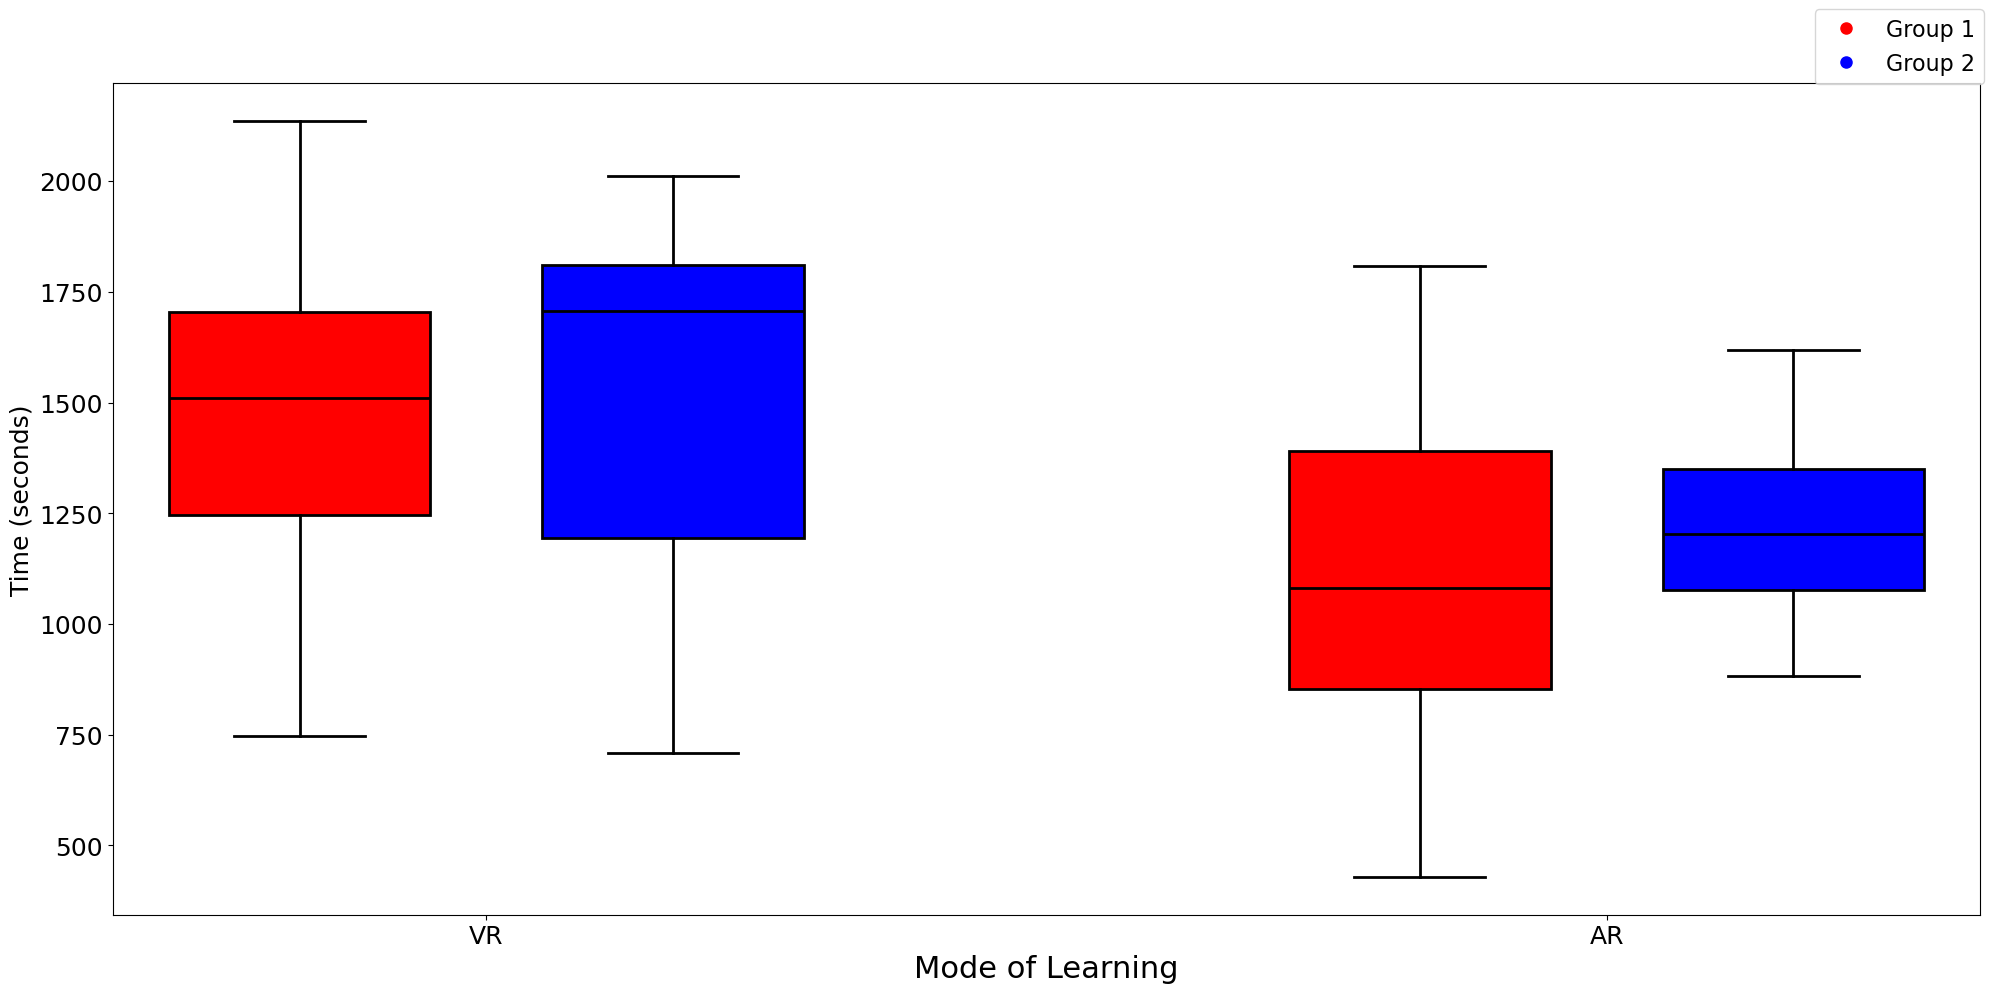

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


group = np.array([1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2])
vr_total_time = np.array([1560, 2012, 1681, 1836, 1239, 709, 1737, 2136, 1511, 1705, 1730, 1265, 1850, 1315, 1246, 973, 748, 1155, 1877])
ar_total_time = np.array([1081, 1478, 1062, 1360, 1809, 1205, 1121, 1440, 854, 1391, 1200, 709, 1361, 1322, 429, 1034, 1032, 1619, 883])


data = pd.DataFrame({
    'Group': group,
    'VR': vr_total_time,
    'AR': ar_total_time
})


fig, ax = plt.subplots(figsize=(20, 10))  


box_data = [
    data[data['Group'] == 1]['VR'],
    data[data['Group'] == 2]['VR'],
    data[data['Group'] == 1]['AR'],
    data[data['Group'] == 2]['AR']
]
box_positions = [1, 2, 4, 5] 

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    patch_artist=True,
    widths=0.7,
    boxprops=dict(linewidth=2),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2),
    flierprops=dict(marker='o', color='black', alpha=0.5)
)

# Set colors for the boxes
colors = ['red', 'blue', 'red', 'blue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)


ax.set_xlabel('Mode of Learning', fontsize=22)
ax.set_ylabel('Time (seconds)', fontsize=18)
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(['VR', 'AR'], fontsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# Custom Legend
red_patch = plt.Line2D([0], [0], color='red', lw=4, label='Group 1')
blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label='Group 2')
fig.legend(handles=[red_circle, blue_circle], loc='upper right', fontsize=16, bbox_to_anchor=(1, 1))


plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('New_Time_Box_Plot_Updated.pdf')
plt.show()


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


file_path = 'knowledgeanalysis.xlsx'  
data = pd.read_excel(file_path, sheet_name='Sheet2')

In [9]:
columns_of_interest = ['Q1LOQ1', 'Q2LOQ1', 'Q3LOQ1', 'Q4LOQ1', 'Q5LOQ1', 'Q6LOQ1',
                       'Q1LOQ2', 'Q2LOQ2', 'Q3LOQ2', 'Q4LOQ2', 'Q5LOQ2', 'Q6LOQ2',
                       'Q1LOQ3', 'Q2LOQ3', 'Q3LOQ3', 'Q4LOQ3', 'Q5LOQ3', 'Q6LOQ3']


filtered_data = data[['Group'] + columns_of_interest]
filtered_data['Participant'] = filtered_data.index + 1


filtered_data.fillna(0, inplace=True)

/var/folders/rx/t5f8jwp17j361gxd76w2pl580000gn/T/ipykernel_2208/367655944.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Participant'] = filtered_data.index + 1
/var/folders/rx/t5f8jwp17j361gxd76w2pl580000gn/T/ipykernel_2208/367655944.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.fillna(0, inplace=True)


/var/folders/rx/t5f8jwp17j361gxd76w2pl580000gn/T/ipykernel_2208/3990627911.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Participant'] = filtered_data.index + 1


<Axes: ylabel='Participant'>

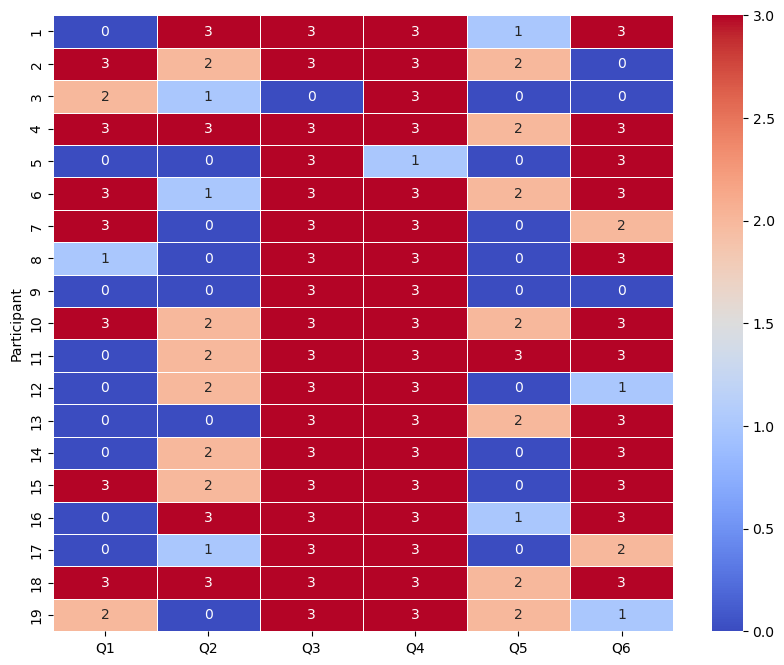

In [11]:
filtered_data = data[['Group'] + columns_of_interest]
filtered_data['Participant'] = filtered_data.index + 1


heatmap_data = pd.DataFrame()


heatmap_data['Q1'] = filtered_data[['Q1LOQ1', 'Q1LOQ2', 'Q1LOQ3']].sum(axis=1)
heatmap_data['Q2'] = filtered_data[['Q2LOQ1', 'Q2LOQ2', 'Q2LOQ3']].sum(axis=1)
heatmap_data['Q3'] = filtered_data[['Q3LOQ1', 'Q3LOQ2', 'Q3LOQ3']].sum(axis=1)
heatmap_data['Q4'] = filtered_data[['Q4LOQ1', 'Q4LOQ2', 'Q4LOQ3']].sum(axis=1)
heatmap_data['Q5'] = filtered_data[['Q5LOQ1', 'Q5LOQ2', 'Q5LOQ3']].sum(axis=1)
heatmap_data['Q6'] = filtered_data[['Q6LOQ1', 'Q6LOQ2', 'Q6LOQ3']].sum(axis=1)


heatmap_data['Participant'] = filtered_data['Participant']


heatmap_data.set_index('Participant', inplace=True)


plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True)


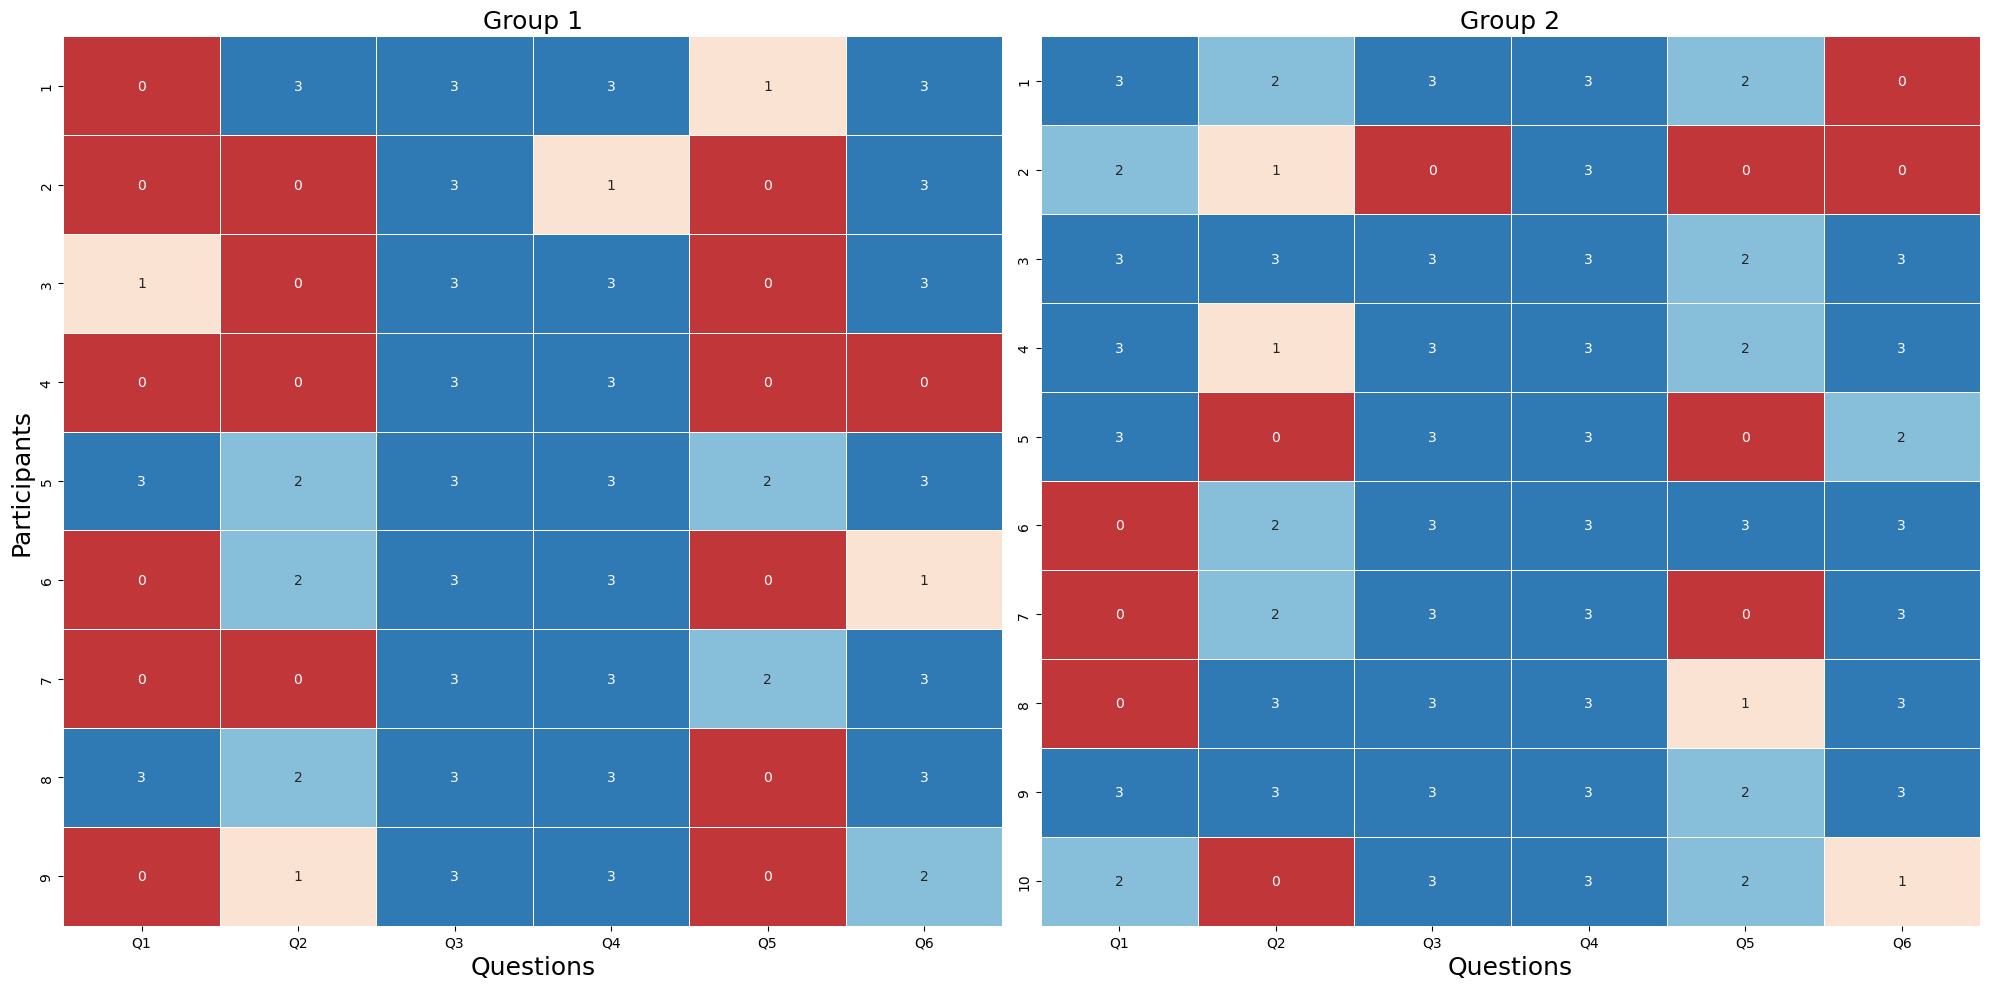

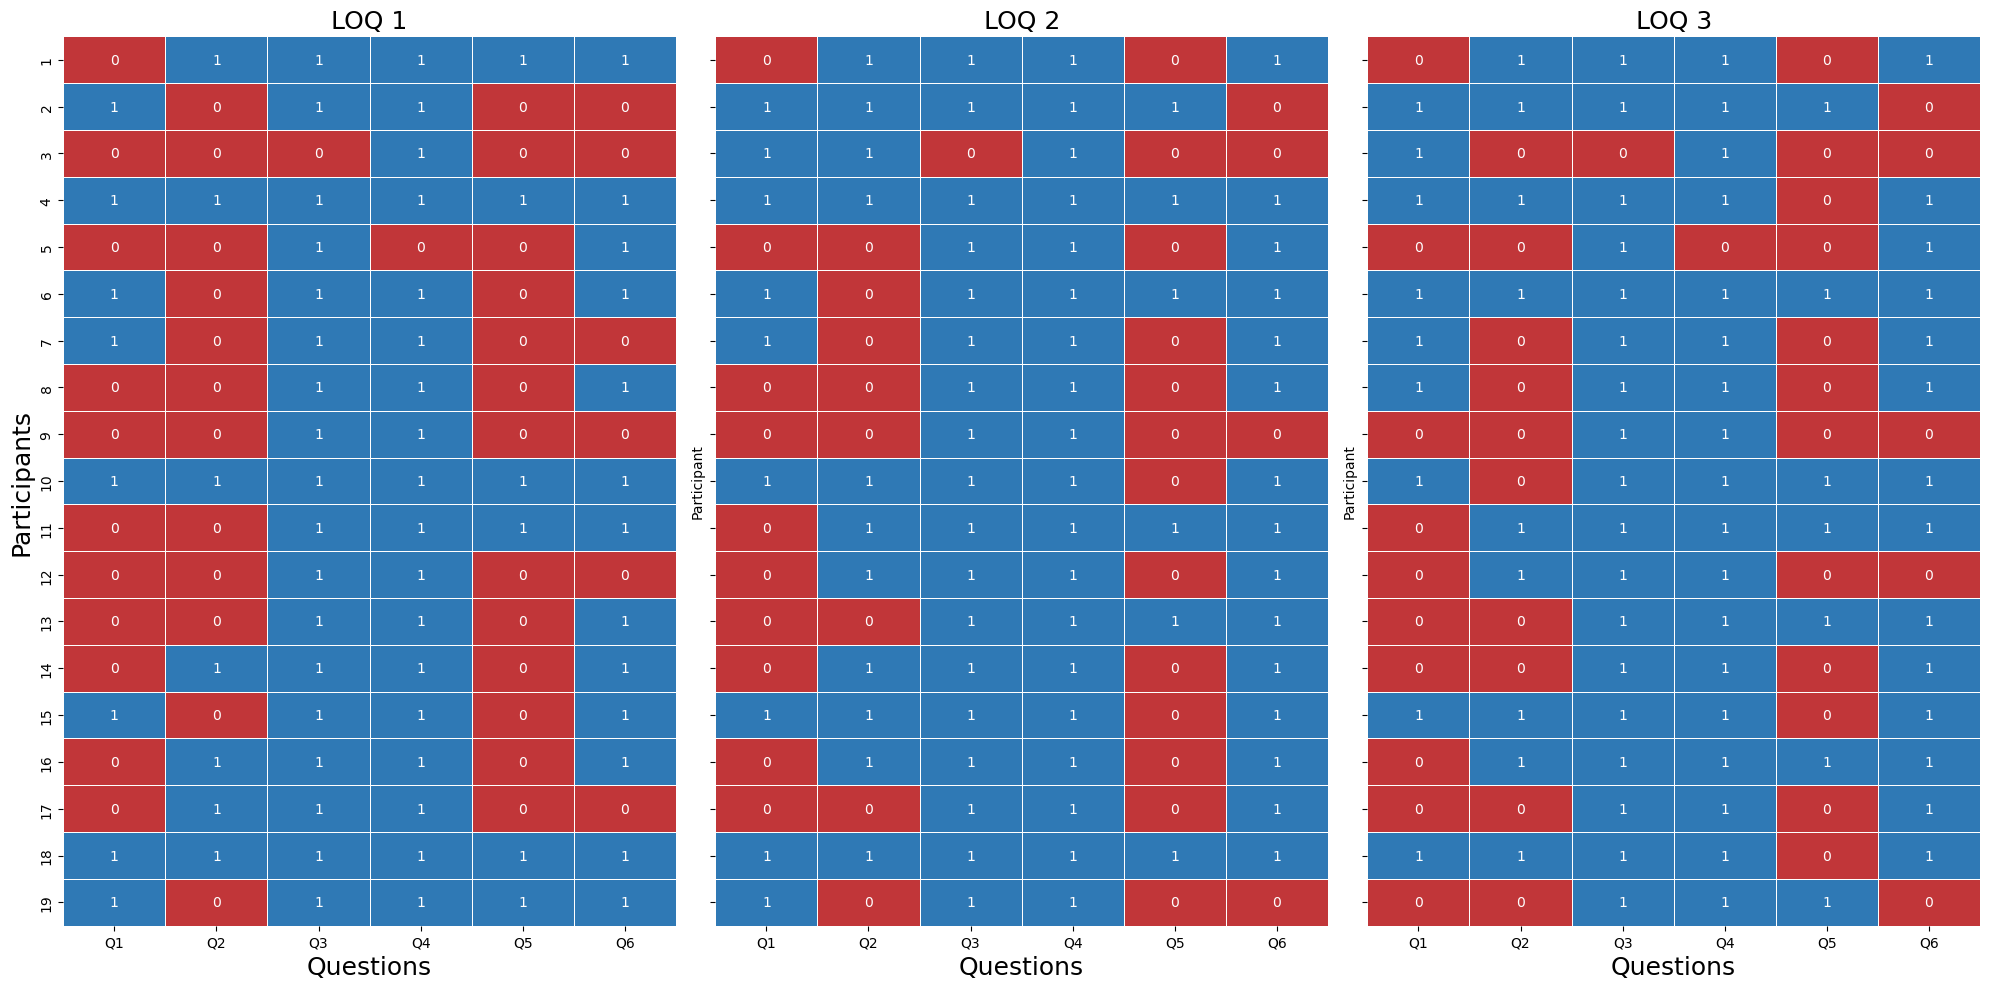

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


file_path = 'knowledgeanalysis.xlsx'
data = pd.read_excel(file_path, sheet_name='Sheet2')


columns_of_interest = [col for col in data.columns if 'LOQ' in col]


data['Participant'] = range(1, len(data) + 1)


filtered_data = data[['Participant', 'Group'] + columns_of_interest]


heatmap_data = pd.DataFrame()
for q in range(1, 7):
    q_columns = [f"Q{q}LOQ{loq}" for loq in range(1, 4)]
    heatmap_data[f'Q{q}'] = filtered_data[q_columns].sum(axis=1)
heatmap_data['Group'] = filtered_data['Group']
heatmap_data['Participant'] = filtered_data['Participant']
cmap = sns.color_palette("RdBu")


group_1_data = heatmap_data[heatmap_data['Group'] == 1].drop(columns=['Group', 'Participant'])
group_2_data = heatmap_data[heatmap_data['Group'] == 2].drop(columns=['Group', 'Participant'])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

sns.heatmap(group_1_data, annot=True, cmap=cmap, linewidths=0.5, cbar=False, ax=ax1, vmin=0, vmax=3, yticklabels=range(1, len(group_1_data) + 1))
ax1.set_title('Group 1', fontsize=18)
ax1.set_xlabel('Questions', fontsize=18)
ax1.set_ylabel('Participants', fontsize=18)

sns.heatmap(group_2_data, annot=True, cmap=cmap, linewidths=0.5, cbar=False, ax=ax2, vmin=0, vmax=3, yticklabels=range(1, len(group_2_data) + 1))
ax2.set_title('Group 2', fontsize=18)
ax2.set_xlabel('Questions', fontsize=18)
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig("NEW_Combined_Heatmap.pdf")
plt.show()


loq_data = filtered_data.set_index('Participant')
fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)

for i, loq in enumerate(range(1, 4)):
    loq_columns = [f"Q{q}LOQ{loq}" for q in range(1, 7)]
    sns.heatmap(
        loq_data[loq_columns],
        annot=True,
        cmap=cmap,
        linewidths=0.5,
        cbar=False,
        ax=axes[i],
        vmin=0,
        vmax=1,
        yticklabels=range(1, len(loq_data) + 1),  # Adjust participant numbers
        xticklabels=[f"Q{q}" for q in range(1, 7)]  # Simplify question labels
    )
    axes[i].set_title(f"LOQ {loq}", fontsize=18)
    axes[i].set_xlabel('Questions', fontsize=18)
    if i == 0:
        axes[i].set_ylabel('Participants', fontsize=18)

plt.tight_layout()
plt.savefig("NEW_Granular_Heatmap.pdf")
plt.show()


/var/folders/rx/t5f8jwp17j361gxd76w2pl580000gn/T/ipykernel_2208/3591047702.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_data.rename(columns={


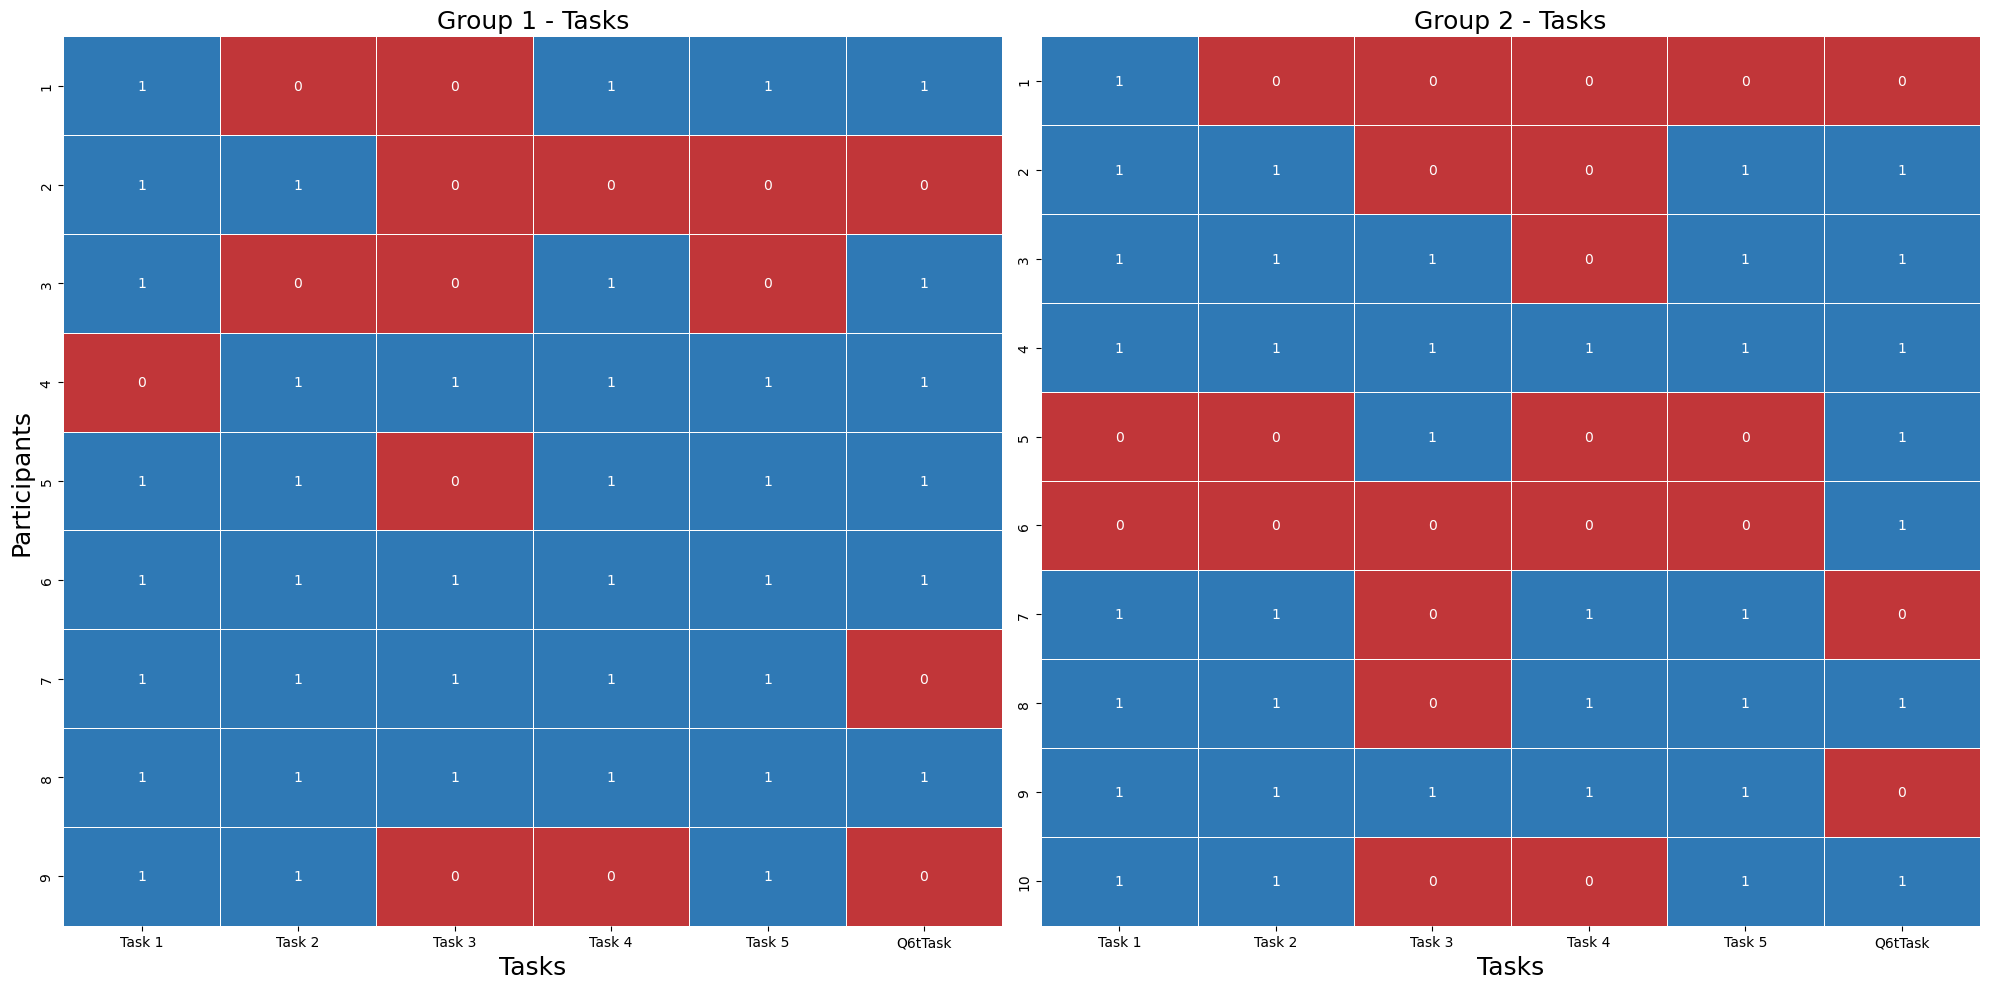

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

file_path = 'knowledgeanalysis.xlsx'
data = pd.read_excel(file_path, sheet_name='Sheet2')

data['Participant'] = range(1, len(data) + 1)


task_data = data[['Participant', 'Group', 'Q1Task', 'Q2Task', 'Q3Task', 'Q4Task', 'Q5Task', 'Q6tTask']]


task_data.rename(columns={
    'Q1Task': 'Task 1', 'Q2Task': 'Task 2', 'Q3Task': 'Task 3',
    'Q4Task': 'Task 4', 'Q5Task': 'Task 5', 'Q6Task': 'Task 6'
}, inplace=True)


group_1_tasks = task_data[task_data['Group'] == 1].drop(columns=['Group']).set_index('Participant')
group_2_tasks = task_data[task_data['Group'] == 2].drop(columns=['Group']).set_index('Participant')

# Create heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
cmap = sns.color_palette("RdBu")

# Heatmap for Group 1
sns.heatmap(group_1_tasks, annot=True, cmap=cmap, linewidths=0.5, cbar=False, ax=ax1, vmin=0, vmax=group_1_tasks.max().max(), yticklabels=range(1, len(group_1_tasks) + 1))
ax1.set_title('Group 1 - Tasks', fontsize=18)
ax1.set_xlabel('Tasks', fontsize=18)
ax1.set_ylabel('Participants', fontsize=18)

# Heatmap for Group 2
sns.heatmap(group_2_tasks, annot=True, cmap=cmap, linewidths=0.5, cbar=False, ax=ax2, vmin=0, vmax=group_2_tasks.max().max(), yticklabels=range(1, len(group_2_tasks) + 1))
ax2.set_title('Group 2 - Tasks', fontsize=18)
ax2.set_xlabel('Tasks', fontsize=18)
ax2.set_ylabel('')


plt.tight_layout()
plt.savefig("NEW_Tasks_Heatmap.pdf")
plt.show()


In [23]:
import pandas as pd
import numpy as np

# Load the data
file_path = 'workload.xlsx'  # Replace with the actual path to your file
data = pd.read_excel(file_path, sheet_name='Sheet1')

# Define the relevant columns
relevant_columns = [
    "LOQ1 How mentally demanding was the task?",
    "LOQ1 How hard did you have to work to accomplish your level of performance?",
    "LOQ 1 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ2 How mentally demanding was the task?",
    "LOQ2 How hard did you have to work to accomplish your level of performance?",
    "LOQ 2 How confident are you to perform the task on the real powder feeder based on your second learning experience?",
    "LOQ 3 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ4 How mentally demanding was the task?",
    "LOQ4 How hard did you have to work to accomplish your level of performance?",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - HL",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - Varjo"
]


data['Participant'] = data.index + 1  

# Split data by group
group_1_data = data[data['Group'] == 1][['Participant'] + relevant_columns]
group_2_data = data[data['Group'] == 2][['Participant'] + relevant_columns]



# Calculate summary statistics for Group 1 and Group 2
group_1_stats = group_1_data[relevant_columns].describe().T
group_2_stats = group_2_data[relevant_columns].describe().T




Participants in Group 1:
[1, 5, 8, 9, 10, 12, 13, 15, 17]

Participants in Group 2:
[2, 3, 4, 6, 7, 11, 14, 16, 18, 19]

Group 1 Summary Statistics:
                                                        mean       std
LOQ1 How mentally demanding was the task?           0.571429  0.188982
LOQ1 How hard did you have to work to accomplis...  0.619048  0.225877
LOQ 1 How confident are you to perform the task...  0.755556  0.194365
LOQ2 How mentally demanding was the task?           0.523810  0.174964
LOQ2 How hard did you have to work to accomplis...  0.476190  0.174964
LOQ 2 How confident are you to perform the task...  0.844444  0.194365
LOQ 3 How confident are you to perform the task...  0.800000  0.200000
LOQ4 How mentally demanding was the task?           0.341111  0.174101
LOQ4 How hard did you have to work to accomplis...  0.310000  0.153867
LOQ4 How satisfied do you feel about the qualit...  0.725556  0.232869
LOQ4 How satisfied do you feel about the qualit...  0.732222  0.177678

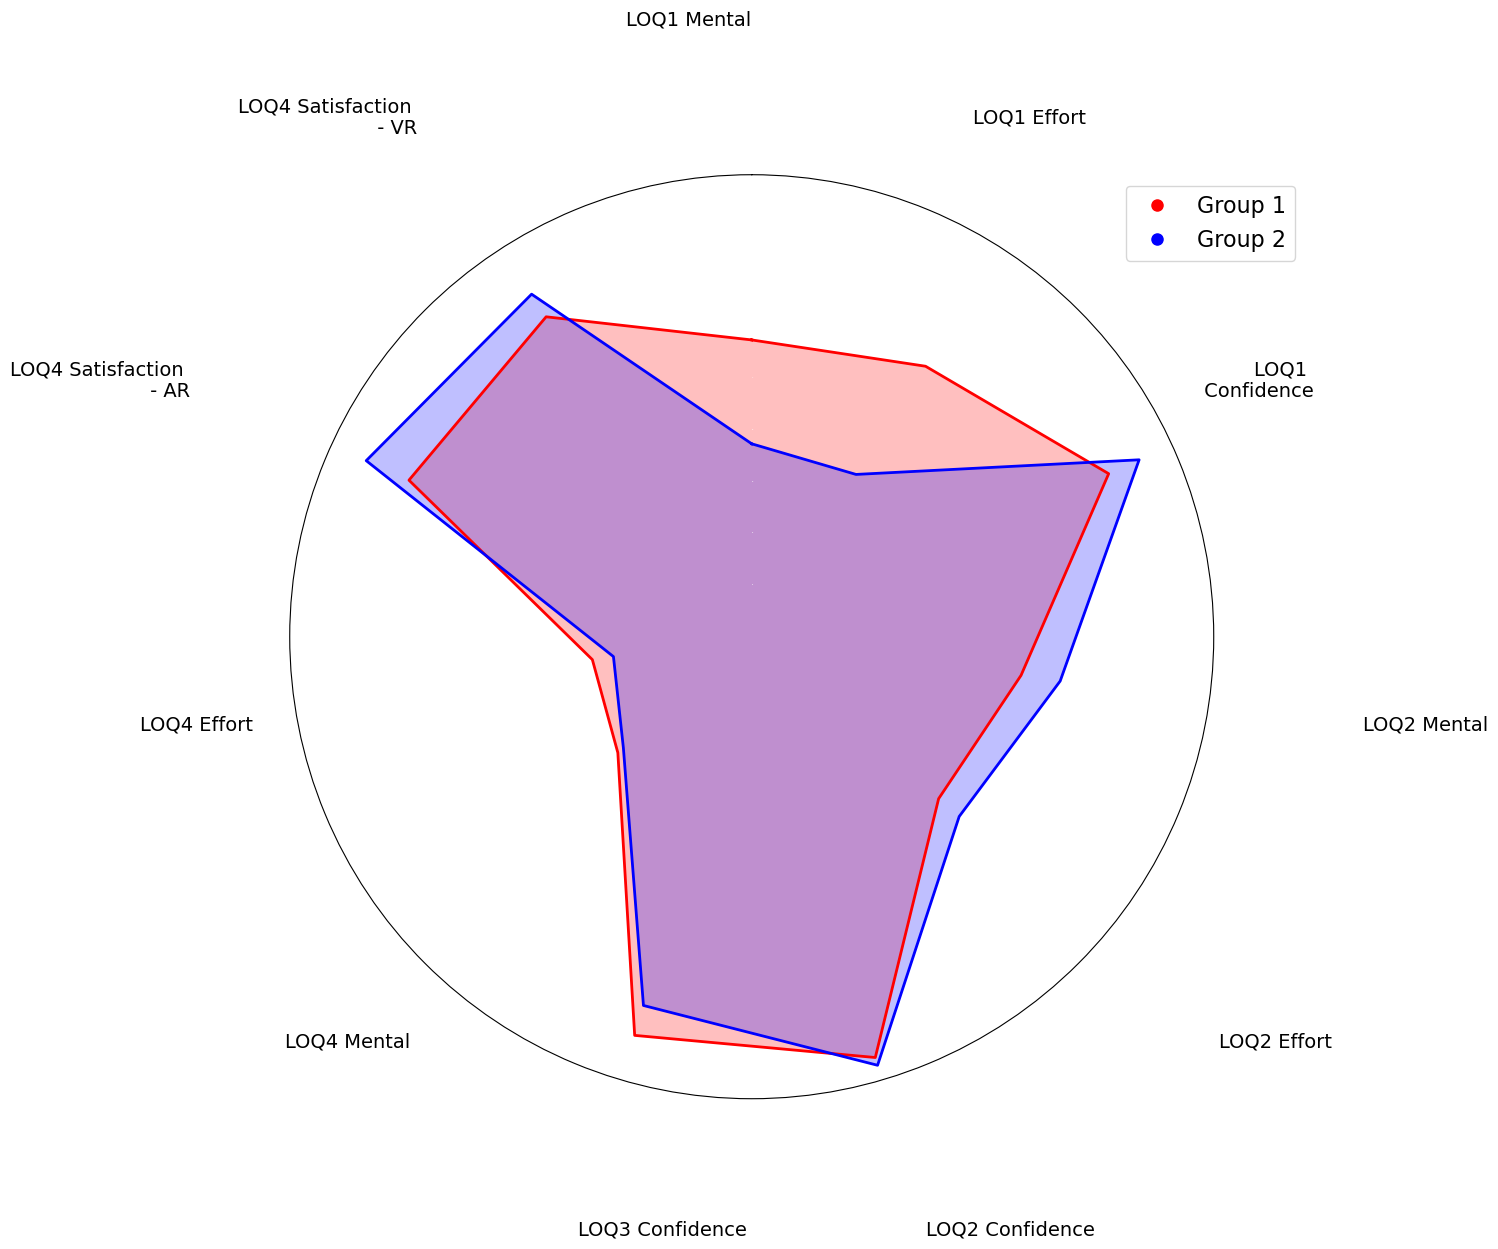

In [25]:
import numpy as np
import matplotlib.pyplot as plt


labels_short = [
    'LOQ1 Mental', 'LOQ1 Effort', 'LOQ1 \n Confidence',
    'LOQ2 Mental', 'LOQ2 Effort', 'LOQ2 Confidence',
    'LOQ3 Confidence',
    'LOQ4 Mental', 'LOQ4 Effort', 'LOQ4 Satisfaction \n - AR',
    'LOQ4 Satisfaction \n  - VR'
]
def create_radar_chart(groups_mean, labels, group_names):
    # Set up radar chart
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop


    fig, ax = plt.subplots(figsize=(20, 12), subplot_kw=dict(polar=True))  # Larger figure size

    # Define colors for each group
    colors = ['red', 'blue']

    # Plot data for each group
    for i, group_mean in enumerate(groups_mean):
        values = group_mean.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, linewidth=2, color=colors[i], label=group_names[i])
        ax.fill(angles, values, color=colors[i], alpha=0.25)

    # Adjust the label positions and spacing
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    label_padding = ax.get_rmax() + 0.3  # Increase padding for the labels
    for i, label in enumerate(labels):
        angle_rad = angles[i]
        ha = 'left' if np.pi / 2 <= angle_rad < 3 * np.pi / 2 else 'right'
        ax.text(
            angle_rad, label_padding, label, size=14, horizontalalignment=ha, verticalalignment='center'
        )

    # Customize radial labels
    ax.set_rlabel_position(0)
    ax.tick_params(colors='white', labelsize=0)  # Hide radial ticks and labels

    # Remove angle measurements and gridlines
    ax.xaxis.set_visible(False)  # Hide angle labels
    ax.grid(False)  # Remove gridlines

    # Add legend
    ax.legend(handles=[red_circle, blue_circle],loc='upper right', bbox_to_anchor=(1.1, 1), fontsize=16)


    file_name = 'NEW_Radar_Chart_Clean.pdf'
    plt.savefig(file_name, bbox_inches='tight')
    plt.show()


group_1_mean = data[data['Group'] == 1][relevant_columns].mean()
group_2_mean = data[data['Group'] == 2][relevant_columns].mean()

create_radar_chart([group_1_mean, group_2_mean], labels_short, ['Group 1', 'Group 2'])


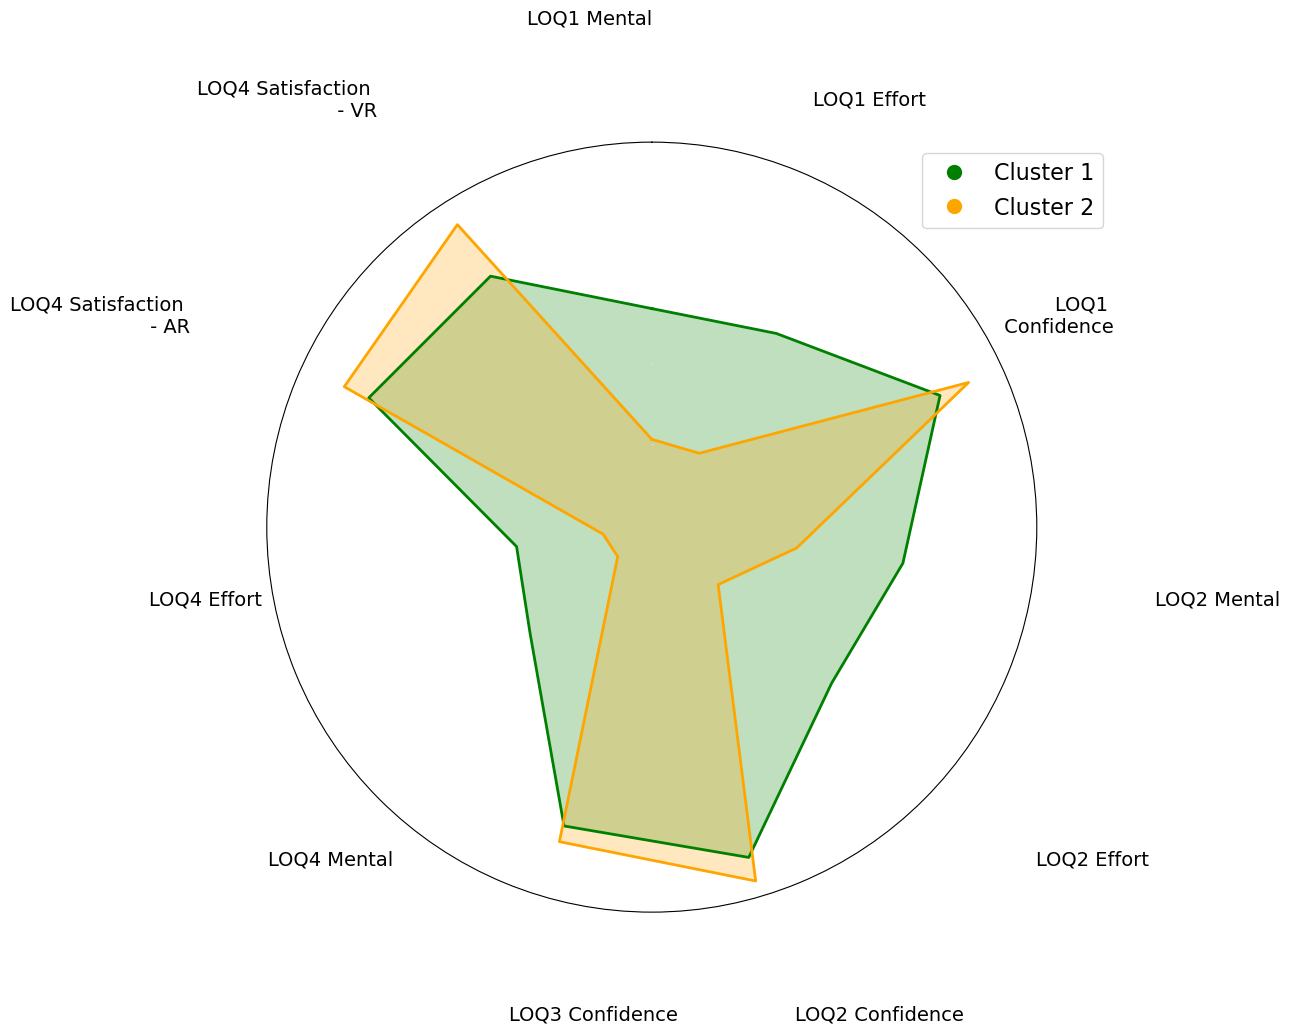

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans


file_path = 'workload.xlsx'  
data = pd.read_excel(file_path, sheet_name='Sheet1')
relevant_columns = [
    "LOQ1 How mentally demanding was the task?",
    "LOQ1 How hard did you have to work to accomplish your level of performance?",
    "LOQ 1 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ2 How mentally demanding was the task?",
    "LOQ2 How hard did you have to work to accomplish your level of performance?",
    "LOQ 2 How confident are you to perform the task on the real powder feeder based on your second learning experience?",
    "LOQ 3 How confident are you to perform the task on the real powder feeder based on your learning experience?",
    "LOQ4 How mentally demanding was the task?",
    "LOQ4 How hard did you have to work to accomplish your level of performance?",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - HL",
    "LOQ4 How satisfied do you feel about the quality of the learning experience you did? - Varjo"
]


kmeans = KMeans(n_clusters=2, random_state=0)
data['Cluster'] = kmeans.fit_predict(data[relevant_columns])


cluster_means = data.groupby('Cluster')[relevant_columns].mean()


labels_short = [
    'LOQ1 Mental', 'LOQ1 Effort', 'LOQ1 \n Confidence',
    'LOQ2 Mental', 'LOQ2 Effort', 'LOQ2 Confidence',
    'LOQ3 Confidence',
    'LOQ4 Mental', 'LOQ4 Effort', 'LOQ4 Satisfaction \n - AR',
    'LOQ4 Satisfaction \n  - VR'
]

# Function to create radar chart for group averages
def create_radar_chart(groups_mean, labels, group_names):
    # Set up radar chart
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop


    fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True))  # Larger figure size


    colors = ['green', 'orange']


    for i, group_mean in enumerate(groups_mean):
        values = group_mean.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, linewidth=2, color=colors[i], label=group_names[i])
        ax.fill(angles, values, color=colors[i], alpha=0.25)

    # Adjust the label positions and spacing
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    label_padding = ax.get_rmax() + 0.3  # Increase padding for the labels
    for i, label in enumerate(labels):
        angle_rad = angles[i]
        ha = 'left' if np.pi / 2 <= angle_rad < 3 * np.pi / 2 else 'right'
        ax.text(
            angle_rad, label_padding, label, size=14, horizontalalignment=ha, verticalalignment='center'
        )

    # Customize radial labels
    ax.set_rlabel_position(0)
    ax.tick_params(colors='white', labelsize=0)  # Hide radial ticks and labels

    # Remove angle measurements and gridlines
    ax.xaxis.set_visible(False)  # Hide angle labels
    ax.grid(False)  # Remove gridlines

    # Add legend with circle markers
    green_circle = plt.Line2D([0], [0], color='green', marker='o', markersize=10, linestyle='None')
    orange_circle = plt.Line2D([0], [0], color='orange', marker='o', markersize=10, linestyle='None')

    ax.legend(
        handles=[green_circle, orange_circle],
        labels=['Cluster 1', 'Cluster 2'],
        loc='upper right',
        bbox_to_anchor=(1.1, 1),
        fontsize=16
    )

    
    file_name = 'NEW_KMeans_Radar_Chart_Circles_Legend.pdf'
    plt.savefig(file_name, bbox_inches='tight')
    plt.show()

create_radar_chart(
    [cluster_means.iloc[0], cluster_means.iloc[1]],
    labels_short,
    ['Cluster 1', 'Cluster 2']
)
